<a href="https://colab.research.google.com/github/Wendell9/N1_IA/blob/main/Modelo_N1_1%C2%BABIMESTRE_ipynb_json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N1 - Inteligência Artificial

Regressão Linear

Nomes:

[Colocar nome e RA dos integrantes do grupo]

*Orientações:*

Esse arquivo contem o modelo esperado de respostas para a N1. Podem ser acrescentadas algumas outras informações ou trechos com códigos, entretanto não esqueçam de responder todos os pontos que foram levantados a seguir

## Exercício X

1. Carregar os dataset do exercício:

In [78]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_white_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-white.csv'

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_red_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-red.csv'

# Carrega o dataset diretamente do GitHub para um DataFrame do pandas
df_redWine = pd.read_csv(github_csv_url_red_wine,sep = ";")
df_whiteWine = pd.read_csv(github_csv_url_white_wine,sep = ";")

2. Fazer a análise exploratória dos dados

(Espera-se no minimo que seja verificado os tipos de dados envolvidos e suas médias, desvios padrões e distribuição dos dados - função describe())

In [79]:
df_redWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [80]:
df_whiteWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [81]:
df_whiteWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [82]:
df_redWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [83]:
df_whiteWine.shape

(4898, 12)

In [84]:
df_whiteWine.duplicated().sum()

np.int64(937)

In [85]:
df_redWine.duplicated().sum()

np.int64(240)

In [86]:
df_whiteWine[df_whiteWine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [87]:
df_redWine[df_redWine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


Os itens considerados 'duplicados' tratam-se de vinhos com os mesmos valores de variáveis e entendo que não necessariamente são duplicados, mas serão dropados justamente pela duplicação de valores que nao serão de valia para o treinamento do modelo, uma vez que podem gerar overfitting e peso desproporcional para determinados padrões.

In [88]:
df_whiteWine.drop_duplicates(inplace=True)
df_whiteWine.shape

(3961, 12)

In [89]:
corr_matrix=df_whiteWine.corr()
corr_matrix['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.462869
pH,0.123829
sulphates,0.053200
free sulfur dioxide,0.010507
citric acid,0.007065
residual sugar,-0.117339
fixed acidity,-0.124636
total sulfur dioxide,-0.183356
volatile acidity,-0.190678


/tmp/ipykernel_740/1250834360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df_whiteWine, ax=axes[i], palette='Set2')
/tmp/ipykernel_740/1250834360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df_whiteWine, ax=axes[i], palette='Set2')
/tmp/ipykernel_740/1250834360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df_whiteWine, ax=axes[i], palette='Set2')
/tmp/ipykernel_740/1250834360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` i

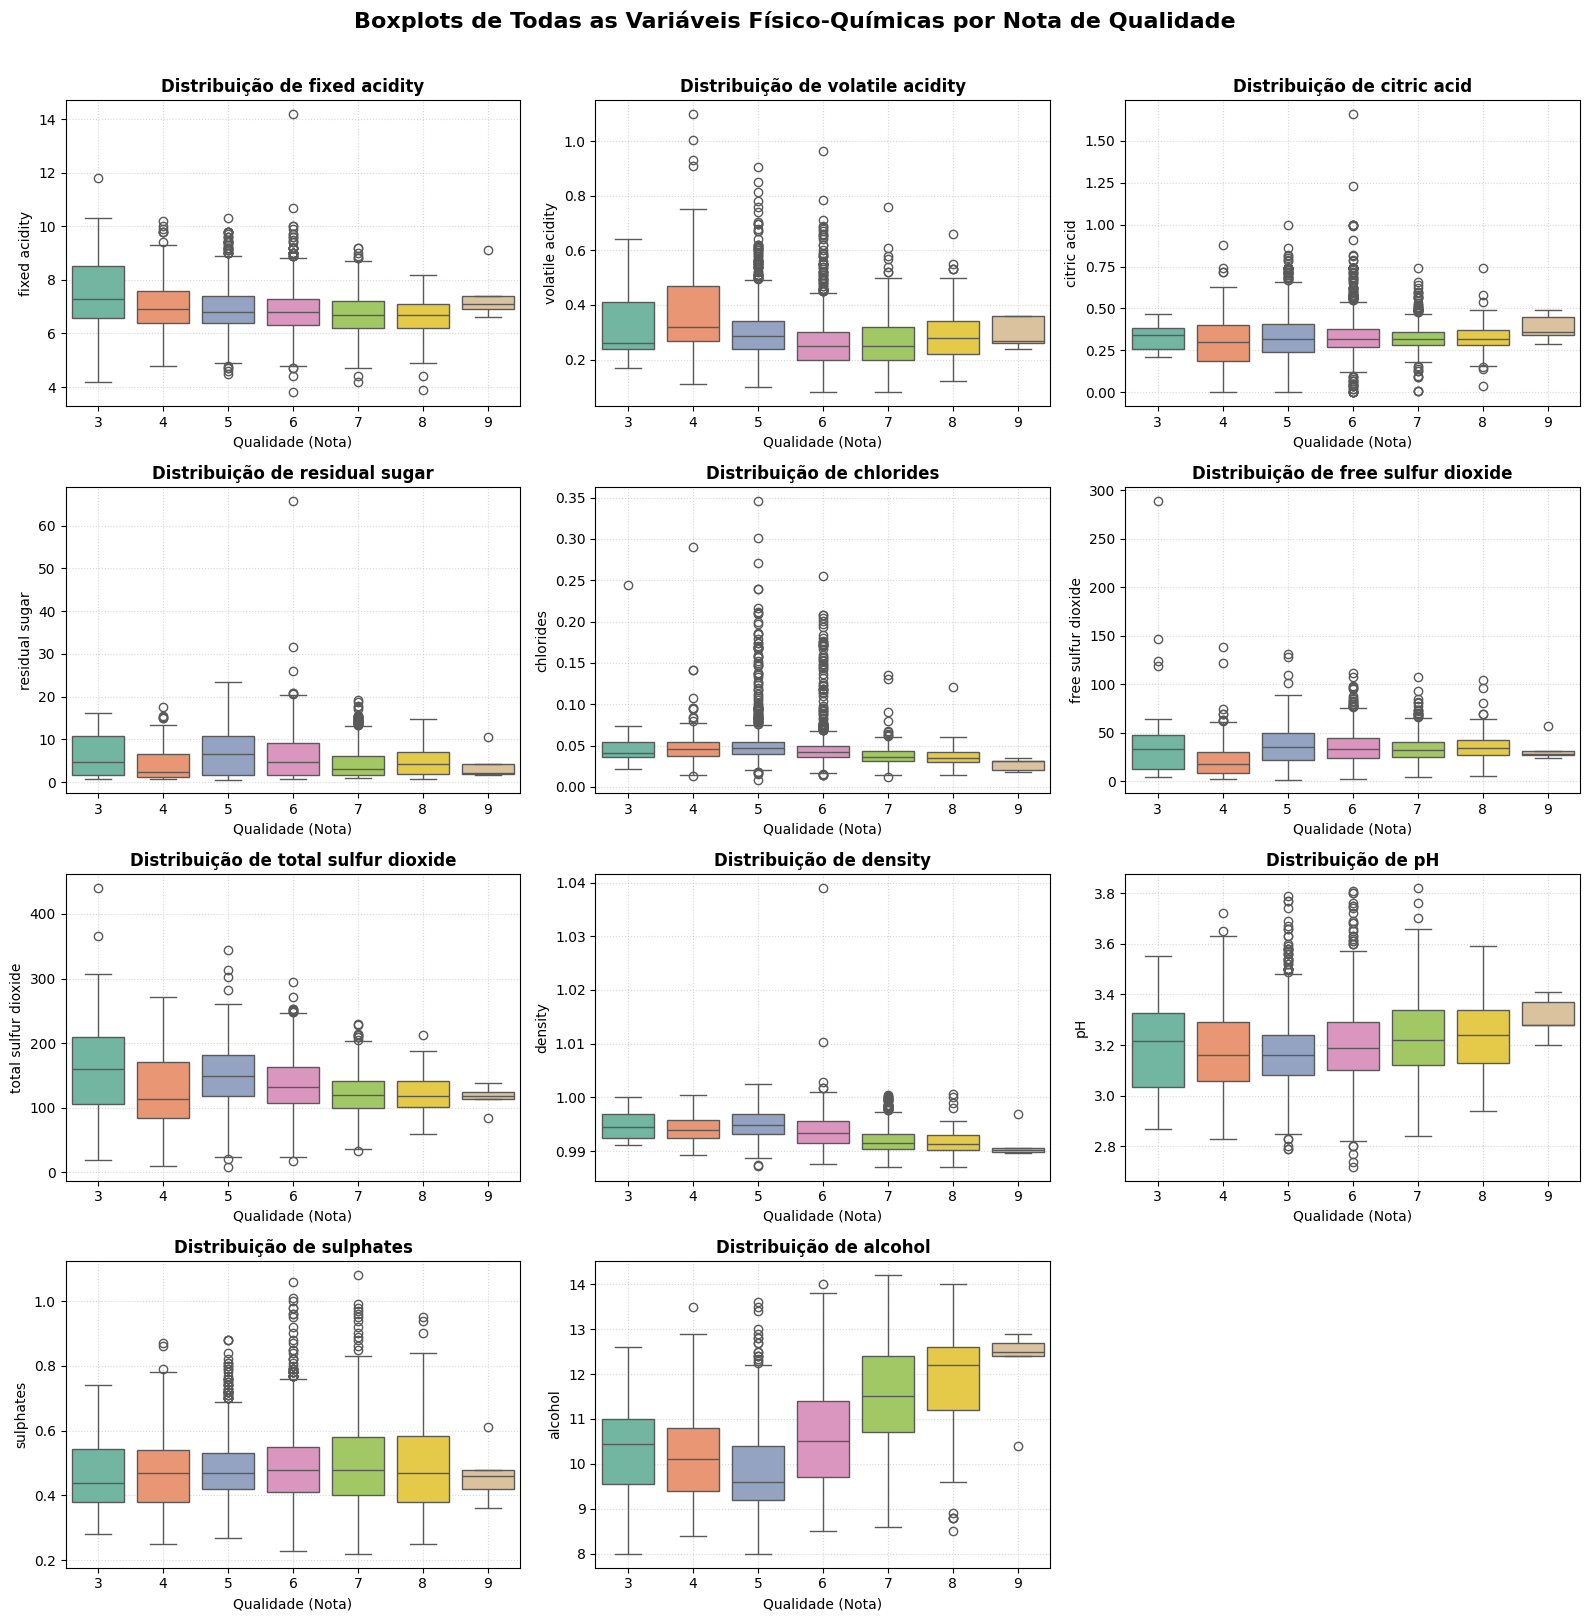

In [104]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionar apenas as colunas numéricas explicativas (excluindo a variável alvo)
features = [col for col in df_whiteWine.columns if col != 'quality']

# 2. Configurar a grade dinamicamente (ex: 3 colunas e quantas linhas forem necessárias)
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()  # Achata a matriz de eixos para iterar facilmente

# 3. Iterar e plotar o boxplot para cada variável
for i, col in enumerate(features):
    sns.boxplot(x='quality', y=col, data=df_whiteWine, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Qualidade (Nota)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.5)

# 4. Remover eixos extras que ficarem em branco na grade (se houver número ímpar)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Boxplots de Todas as Variáveis Físico-Químicas por Nota de Qualidade',
    fontsize=16,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
plt.show()

OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

As features são alcohol, pH,sulphates,free sulfur dioxide,citric acid, residual sugar, fixed acidity, total sulfur dioxide, chiorides,density. Por sua vez, a variável alvo é quality.

In [90]:
# Define X by dropping only the target variable 'quality'
# All other columns in df_whiteWineTratado should now be treated as features,
# including the new custom, log-transformed, and polynomial features.
X = df_whiteWine.drop(columns=['quality'])
y = df_whiteWine['quality']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

# Regressão Linear

In [92]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Padronize os dados de treino e teste
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lin = LinearRegression()

scores = cross_val_score(
    model_lin, X_train_scaled, y_train, cv=5, scoring='r2'
)

model_lin.fit(X_train_scaled, y_train)

y_pred_lin = model_lin.predict(X_test_scaled)

# Arvore de Decisão

In [93]:
X = df_whiteWine.drop(columns=['quality'])
y = df_whiteWine['quality']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

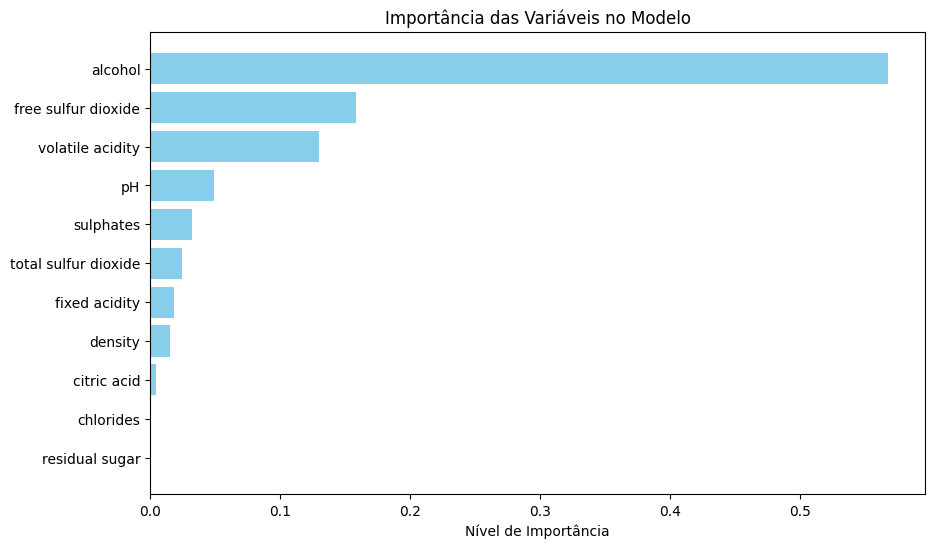

In [95]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

model_dtr = DecisionTreeRegressor(random_state=42, max_depth=5)
scores = cross_val_score(
    model_dtr, X_train, y_train, cv=5, scoring='r2'
)
model_dtr.fit(X_train, y_train)

y_pred_dtr = model_dtr.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_dtr.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Random Forest

In [96]:
# Define X by dropping only the target variable 'quality'
# All other columns in df_whiteWineTratado should now be treated as features,
# including the new custom, log-transformed, and polynomial features.
X = df_whiteWine.drop(columns=['quality'])
y = df_whiteWine['quality']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

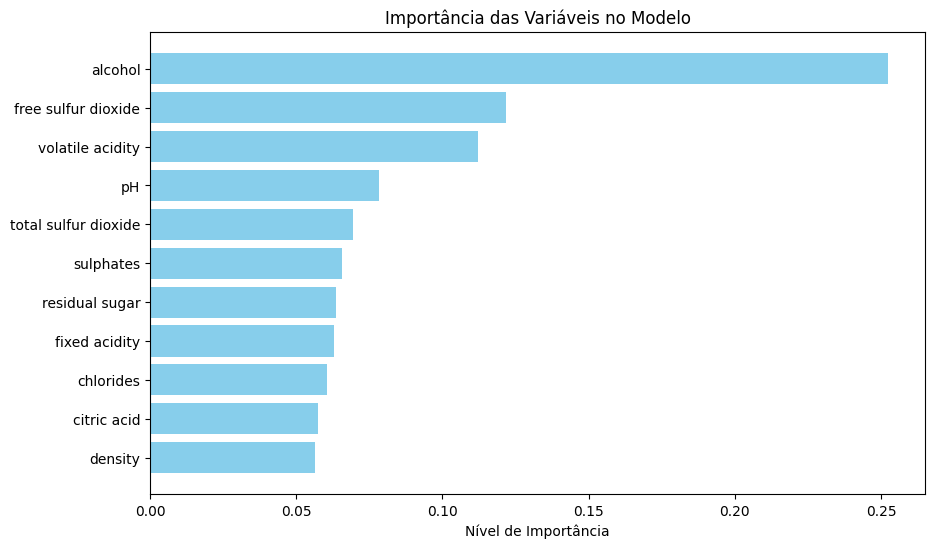

In [98]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100,
                                  random_state=42)
scores = cross_val_score(
    model_rf, X_train, y_train, cv=5, scoring='r2'
)
model_rf.fit(X_train, y_train)


y_pred_rf = model_rf.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_rf.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Suport Vector Regressor (SVR)

In [99]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1. Padronize os dados de treino e teste para SVR
scaler_svr = StandardScaler()
X_train_scaled_svr = scaler_svr.fit_transform(X_train)
X_test_scaled_svr = scaler_svr.transform(X_test)

model_svr = SVR(kernel='rbf', C=100, gamma=0.1)

scores = cross_val_score(
    model_svr, X_train_scaled_svr, y_train, cv=5, scoring='r2'
)

model_svr.fit(X_train_scaled_svr, y_train)

y_pred_svr = model_svr.predict(X_test_scaled_svr)

# XGBoost Regressor

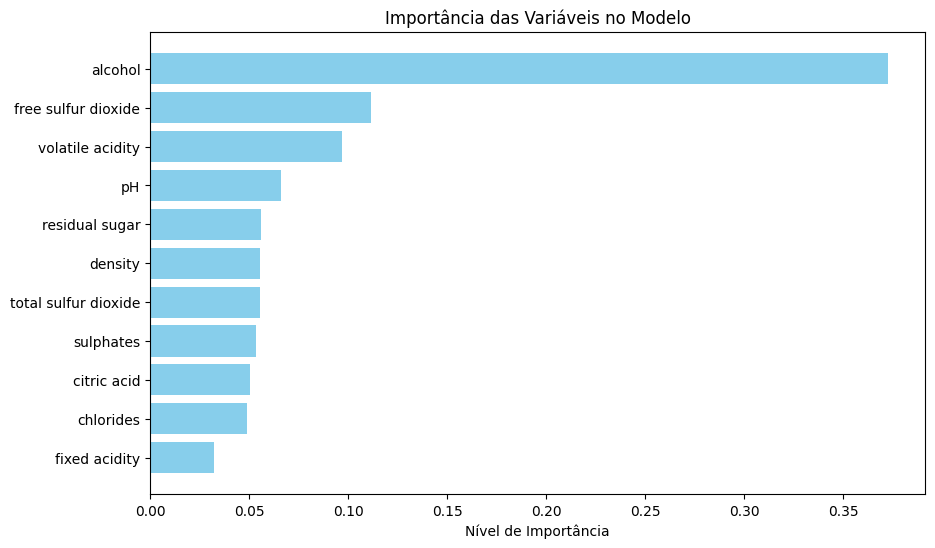

In [100]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

scores = cross_val_score(
    model_xgb, X_train, y_train, cv=5, scoring='r2'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

# 3. Extraia a importância e crie um DataFrame para visualizar
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_xgb.feature_importances_
})

# 4. Ordene da maior para a menor importância
importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

## Redes Neurais Artificiais (MLP)

In [101]:
from sklearn.neural_network import MLPRegressor

# Using the scaled data from the Linear Regression section
# X_train_scaled and X_test_scaled are already available.

model_mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, solver='adam')

scores = cross_val_score(
    model_mlp, X_train_scaled, y_train, cv=5, scoring='r2'
)

model_mlp.fit(X_train_scaled, y_train)

y_pred_mlp = model_mlp.predict(X_test_scaled)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


4. Metricas de desempenho

(Usar as métricas de desempenho para comparar os resultados)

In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(y_true, y_pred, model_name=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  MSE = {mse:.4f}")
    print(f"  MAE = {mae:.4f}")
    print(f"  R²  = {r2:.4f}")
    print("-"*30)

# Métricas para cada modelo
print_metrics(y_test, y_pred_lin, "LinearRegression")
print_metrics(y_test, y_pred_dtr, "DecisionTreeRegressor")
print_metrics(y_test, y_pred_rf,  "RandomForestRegressor")
print_metrics(y_test, y_pred_svr, "SVR")
print_metrics(y_test, y_pred_xgb, "XGBRegressor")
print_metrics(y_test, y_pred_mlp, "MLPRegressor")

LinearRegression:
  MSE = 0.5788
  MAE = 0.5867
  R²  = 0.2703
------------------------------
DecisionTreeRegressor:
  MSE = 0.6140
  MAE = 0.6029
  R²  = 0.2260
------------------------------
RandomForestRegressor:
  MSE = 0.4884
  MAE = 0.5409
  R²  = 0.3843
------------------------------
SVR:
  MSE = 0.7306
  MAE = 0.6543
  R²  = 0.0789
------------------------------
XGBRegressor:
  MSE = 0.5088
  MAE = 0.5566
  R²  = 0.3586
------------------------------
MLPRegressor:
  MSE = 0.7065
  MAE = 0.6448
  R²  = 0.1093
------------------------------


5. Conclusão

Qual dos modelos conseguiu o melhor desempenho?